# Análisis Citus — PostgreSQL Distribuido + Búsqueda Textual
**BD2 Lab 16: MongoDB Distribuido vs Citus**

Dataset: News Headlines About President Milei (2,224 registros únicos)

**Nota:** Este notebook funciona sin conexión a Citus para tablas/gráficos.
Para `EXPLAIN ANALYZE` requiere el cluster Citus activo.

In [1]:
import pandas as pd
import json
from datetime import datetime
import matplotlib.pyplot as plt

DATA_FILE = r"../../dataset/processed/milei_news_clean.json"

DB_CONFIG = {
    "host": "localhost",
    "port": 5435,  # el 5432 del host lo ocupa un PostgreSQL 17 local
    "dbname": "news_analysis_pg",
    "user": "postgres",
    "password": "postgres",
}

df = pd.read_json(DATA_FILE)
print(f"Registros cargados: {len(df)}")
df.head(3)

Registros cargados: 2224


,news_paper,section,title,summary,published,link,tags,credit
0,AgenciaTélam,Cono Sur,El Gobierno chileno confirmó la asistencia de ...,Desde el vecino país señalaron la presencia de...,2023-11-22 13:16:00,https://www.telam.com.ar/notas/202311/647376-b...,,
1,AgenciaTélam,Cono Sur,"Arce advierte que ""hay que parar las orejas"" s...","El mandatario boliviano dijo que ""el discurso ...",2023-12-14 17:41:00,https://www.telam.com.ar/notas/202312/649559-b...,,
2,AgenciaTélam,Cono Sur,Ministro de Lula duda sobre la efectividad del...,El titular de Hacienda del vecino país se preg...,2024-01-02 11:37:00,https://www.telam.com.ar/notas/202401/651285-b...,,


---
## P6: Estadísticas del Dataset y configuración Citus

In [2]:
print("=== TABLA DE ESTADÍSTICAS ===")
print(f"Registros totales: {len(df)}")
print(f"Secciones únicas: {df['section'].nunique()}")
print(f"Periódicos únicos: {df['news_paper'].nunique()}")
print(f"Registros sin summary: {(df['summary'] == '').sum()}")
print(f"Registros sin fecha: {df['published'].isna().sum()}")

print(f"\nDistribución de secciones (top 15):")
print(df['section'].value_counts().head(15).to_string())

print(f"\nDistribución de periódicos:")
print(df['news_paper'].value_counts().to_string())

=== TABLA DE ESTADÍSTICAS ===
Registros totales: 2224
Secciones únicas: 70
Periódicos únicos: 20
Registros sin summary: 121
Registros sin fecha: 0

Distribución de secciones (top 15):
section
Política              458
Economía              322
Deportes              132
El País               120
Últimas noticias      113
Adncultura            109
Actualidad            102
Portada                90
Negocios               88
Sociedad               80
Opinión                72
País y Mundo           60
Nacional               44
El País y el Mundo     43
Provincia              37

Distribución de periódicos:
news_paper
AmbitoFinanciero        466
Perfil                  393
lapoliticaonline        273
Pagina12                266
diariocronica           224
ElTerritorio            165
BigBangNews             131
Clarin                  115
AgenciaTélam             67
ElPaís                   51
NuevoDiarioWeb           48
LaNacion                 10
todoagro                  3
AlJazeera     

## P7: Estrategia de distribución Citus

Al igual que en MongoDB, se usa `section` como clave de distribución con **hash**.
Citus distribuye las filas entre los workers según el hash de `section`.

Ventajas:
- Q4 (GROUP BY section) es local a cada worker
- Q5 (GROUP BY news_paper) requiere scatter/gather

In [ ]:
section_dist = df['section'].value_counts()
print(f"Cardinalidad de section: {len(section_dist)}")
print(f"Estrategia elegida: HASH")
print(f"Razón: Distribución sesgada (Política domina) -> hash balancea entre workers")

---
## Q1–Q5: Queries Citus

### Requiere conexión a Citus (cluster activo)

In [3]:
CITUS_AVAILABLE = False
times = {}  # tiempos de Q1-Q5 en ms (para la tabla pandas de P9)
try:
    import psycopg2
    conn = psycopg2.connect(**DB_CONFIG)
    cursor = conn.cursor()
    CITUS_AVAILABLE = True
    print("Conexión a Citus exitosa.")
except Exception as e:
    print(f"No se pudo conectar a Citus: {e}")
    print("Las queries requieren el cluster activo.")

Conexión a Citus exitosa.


In [4]:
if CITUS_AVAILABLE:
    cursor.execute("SELECT * FROM master_get_active_worker_nodes()")
    workers = cursor.fetchall()
    print("=== Workers activos ===")
    for w in workers:
        print(f"  {w[0]}:{w[1]}")
else:
    print("Workers: pendiente (activo cluster)")

=== Workers activos ===
  worker2:5432
  worker1:5432


### Q1: Búsqueda textual múltiples términos

In [9]:
if CITUS_AVAILABLE:
    import time
    
    sql = """
    SELECT title, section, 
           ts_rank(to_tsvector('spanish', coalesce(title,'') || ' ' || coalesce(summary,'')),
                   to_tsquery('spanish', 'dolar & inflacion')) AS rank
    FROM milei_news
    WHERE to_tsvector('spanish', coalesce(title,'') || ' ' || coalesce(summary,'')) @@ to_tsquery('spanish', 'dolar & inflacion')
    ORDER BY rank DESC
    LIMIT 20;
    """
    
    start = time.time()
    cursor.execute(sql)
    results = cursor.fetchall()
    elapsed = time.time() - start
    times['Q1'] = round(elapsed * 1000, 2)
    
    cursor.execute("EXPLAIN ANALYZE " + sql)
    explain = cursor.fetchall()
    
    print(f"Q1 - Tiempo: {elapsed*1000:.2f} ms")
    print(f"Q1 - Resultados: {len(results)}")
    print(f"\nTop 5:")
    for r in results[:5]:
        print(f"  [{r[2]:.3f}] {r[0][:60]} - {r[1]}")
    print(f"\n--- EXPLAIN ANALYZE ---")
    for line in explain[:20]:
        print(line[0])
else:
    print("Q1: Requiere conexión Citus.")

Q1 - Tiempo: 7.07 ms
Q1 - Resultados: 5

Top 5:
  [0.099] Las definiciones económicas de Javier Milei: inflación, dóla - Últimas noticias
  [0.097] Lo que se dice en las mesas: habló el mercado y ahora la pel - Economía
  [0.022] De la tablita cambiaria de Martínez de Hoz a la tablita camb - Economía
  [0.003] Carlos Melconian, criticó duro al gobierno de Javier Milei:  - Deportes
  [0.000] Javier Milei sobre el dólar: "No tiene ningún sentido aceler - Últimas noticias

--- EXPLAIN ANALYZE ---
Limit  (cost=2660.96..2661.01 rows=20 width=68) (actual time=8.496..8.497 rows=5 loops=1)
  ->  Sort  (cost=2660.96..2910.96 rows=100000 width=68) (actual time=8.495..8.496 rows=5 loops=1)
        Sort Key: remote_scan.rank DESC
        Sort Method: quicksort  Memory: 25kB
        ->  Custom Scan (Citus Adaptive)  (cost=0.00..0.00 rows=100000 width=68) (actual time=8.488..8.489 rows=5 loops=1)
              Task Count: 32
              Tuple data received from nodes: 506 bytes
              Tasks

### Q2: Búsqueda con exclusión

In [27]:
if CITUS_AVAILABLE:
    import time
    
    sql = """
    SELECT title, published
    FROM milei_news
    WHERE to_tsvector('spanish', coalesce(title,'') || ' ' || coalesce(summary,'')) @@ to_tsquery('spanish', 'Milei & !Twitter')
    ORDER BY published DESC
    LIMIT 20;
    """
    
    start = time.time()
    cursor.execute(sql)
    results = cursor.fetchall()
    elapsed = time.time() - start
    times['Q2'] = round(elapsed * 1000, 2)
    
    cursor.execute("EXPLAIN ANALYZE " + sql)
    explain = cursor.fetchall()
    
    print(f"Q2 - Tiempo: {elapsed*1000:.2f} ms")
    print(f"Q2 - Resultados: {len(results)}")
    print(f"\nTop 5:")
    for r in results[:5]:
        print(f"  {r[1]} - {r[0][:60]}")
    print(f"\n--- EXPLAIN ANALYZE ---")
    for e in explain[:20]:
        print(e[0])
else:
    print("Q2: Requiere conexión Citus.")

Q2 - Tiempo: 13.77 ms
Q2 - Resultados: 20

Top 5:
  2024-12-23 00:00:00 - Corte Suprema: el decreto de Milei puede convertirse en "kri
  2024-12-22 12:17:00 - Dólar: Javier Milei dio la hoja de ruta para salir del cepo 
  2024-12-21 23:06:57 - Milei va a contracorriente del mundo
  2024-12-21 21:33:30 - Pino dijo que la relación del campo con Milei es “buena y re
  2024-12-21 20:00:00 - Milei Vs. Villarruel: una pelea que ninguno de los dos está 

--- EXPLAIN ANALYZE ---
Limit  (cost=2660.96..2661.01 rows=20 width=40) (actual time=14.609..14.613 rows=20 loops=1)
  ->  Sort  (cost=2660.96..2910.96 rows=100000 width=40) (actual time=14.608..14.610 rows=20 loops=1)
        Sort Key: remote_scan.published DESC
        Sort Method: top-N heapsort  Memory: 31kB
        ->  Custom Scan (Citus Adaptive)  (cost=0.00..0.00 rows=100000 width=40) (actual time=14.554..14.573 rows=404 loops=1)
              Task Count: 32
              Tuple data received from nodes: 38 kB
              Tasks Shown:

### Q3: Top 10 por fecha

In [17]:
if CITUS_AVAILABLE:
    import time
    
    sql = """
    SELECT title, published, section, news_paper
    FROM milei_news
    ORDER BY published DESC
    LIMIT 10;
    """
    
    start = time.time()
    cursor.execute(sql)
    results = cursor.fetchall()
    elapsed = time.time() - start
    times['Q3'] = round(elapsed * 1000, 2)
    
    cursor.execute("EXPLAIN ANALYZE " + sql)
    explain = cursor.fetchall()
    
    print(f"Q3 - Tiempo: {elapsed*1000:.2f} ms")
    print(f"\nTop 10:")
    for i, r in enumerate(results, 1):
        print(f"  {i}. {r[1]} - {r[0][:60]}")
    print(f"\n--- EXPLAIN ANALYZE ---")
    for e in explain[:20]:
        print(e[0])
else:
    print("Q3: Requiere conexión Citus.")

Q3 - Tiempo: 5.52 ms

Top 10:
  1. 2024-12-23 00:00:00 - Corte Suprema: el decreto de Milei puede convertirse en "kri
  2. 2024-12-22 12:17:00 - Dólar: Javier Milei dio la hoja de ruta para salir del cepo 
  3. 2024-12-21 23:06:57 - Milei va a contracorriente del mundo
  4. 2024-12-21 21:33:30 - Pino dijo que la relación del campo con Milei es “buena y re
  5. 2024-12-21 20:00:00 - Milei Vs. Villarruel: una pelea que ninguno de los dos está 
  6. 2024-12-21 19:28:53 - Giorgia Meloni, el Papa Francisco, un gobernador peronista y
  7. 2024-12-21 17:19:00 - Salida del cepo: asesor de Javier Milei aseguró que "no se n
  8. 2024-12-21 16:14:27 - Karina Milei y Martin Menem visitarán Posadas el próximo vie
  9. 2024-12-21 16:07:24 - Margarita Barrientos y el gobierno de Milei: "Nosotros venim
  10. 2024-12-21 12:30:00 - Federico Sturzenegger publicó el listado de "las más de 200 

--- EXPLAIN ANALYZE ---
Limit  (cost=2160.96..2160.99 rows=10 width=104) (actual time=6.456..6.458 rows=10 loops

### Q4: Agregación por shard key (section)

In [21]:
if CITUS_AVAILABLE:
    import time
    
    sql = """
    SELECT section, COUNT(*) as cnt
    FROM milei_news
    GROUP BY section
    ORDER BY cnt DESC;
    """
    
    start = time.time()
    cursor.execute(sql)
    results = cursor.fetchall()
    elapsed = time.time() - start
    times['Q4'] = round(elapsed * 1000, 2)
    
    cursor.execute("EXPLAIN ANALYZE " + sql)
    explain = cursor.fetchall()
    
    print(f"Q4 - Tiempo: {elapsed*1000:.2f} ms")
    print(f"\nSecciones (top 10):")
    for r in results[:10]:
        print(f"  {r[0]}: {r[1]}")
    print(f"\n--- EXPLAIN ANALYZE ---")
    for e in explain[:25]:
        print(e[0])
else:
    print("Q4: Requiere conexión Citus.")

Q4 - Tiempo: 5.00 ms

Secciones (top 10):
  Política: 458
  Economía: 322
  Deportes: 132
  El País: 120
  Últimas noticias: 113
  Adncultura: 109
  Actualidad: 102
  Portada: 90
  Negocios: 88
  Sociedad: 80

--- EXPLAIN ANALYZE ---
Sort  (cost=11041.82..11291.82 rows=100000 width=40) (actual time=7.189..7.193 rows=70 loops=1)
  Sort Key: remote_scan.cnt DESC
  Sort Method: quicksort  Memory: 28kB
  ->  Custom Scan (Citus Adaptive)  (cost=0.00..0.00 rows=100000 width=40) (actual time=7.161..7.177 rows=70 loops=1)
        Task Count: 32
        Tuple data received from nodes: 1298 bytes
        Tasks Shown: One of 32
        ->  Task
              Tuple data received from node: 70 bytes
              Node: host=worker2 port=5432 dbname=news_analysis_pg
              ->  HashAggregate  (cost=36.09..36.12 rows=3 width=18) (actual time=0.130..0.131 rows=3 loops=1)
                    Group Key: section
                    Batches: 1  Memory Usage: 24kB
                    ->  Seq Scan on 

### Q5: Agregación por atributo no particionado (news_paper)

In [24]:
if CITUS_AVAILABLE:
    import time
    
    sql = """
    SELECT news_paper, COUNT(*) as cnt
    FROM milei_news
    GROUP BY news_paper
    ORDER BY cnt DESC;
    """
    
    start = time.time()
    cursor.execute(sql)
    results = cursor.fetchall()
    elapsed = time.time() - start
    times['Q5'] = round(elapsed * 1000, 2)
    
    cursor.execute("EXPLAIN ANALYZE " + sql)
    explain = cursor.fetchall()
    
    print(f"Q5 - Tiempo: {elapsed*1000:.2f} ms")
    print(f"\nPeriódicos:")
    for r in results:
        print(f"  {r[0]}: {r[1]}")
    print(f"\n--- EXPLAIN ANALYZE ---")
    for e in explain[:25]:
        print(e[0])
else:
    print("Q5: Requiere conexión Citus.")

Q5 - Tiempo: 5.81 ms

Periódicos:
  AmbitoFinanciero: 466
  Perfil: 393
  lapoliticaonline: 273
  Pagina12: 266
  diariocronica: 224
  ElTerritorio: 165
  BigBangNews: 131
  Clarin: 115
  AgenciaTélam: 67
  ElPaís: 51
  NuevoDiarioWeb: 48
  LaNacion: 10
  AlJazeera: 3
  todoagro: 3
  TheNewYorkTimes: 2
  TheGuardian: 2
  LosAngelesTimes: 2
  France24: 1
  TheWashingtonPost: 1
  TheWallStreetJournal: 1

--- EXPLAIN ANALYZE ---
Sort  (cost=511.14..511.64 rows=200 width=40) (actual time=6.436..6.437 rows=20 loops=1)
  Sort Key: (COALESCE((pg_catalog.sum(remote_scan.cnt))::bigint, '0'::bigint)) DESC
  Sort Method: quicksort  Memory: 25kB
  ->  HashAggregate  (cost=500.00..503.50 rows=200 width=40) (actual time=6.425..6.430 rows=20 loops=1)
        Group Key: remote_scan.news_paper
        Batches: 1  Memory Usage: 40kB
        ->  Custom Scan (Citus Adaptive)  (cost=0.00..0.00 rows=100000 width=40) (actual time=6.390..6.398 rows=107 loops=1)
              Task Count: 32
              Tuple

---
## P9: Tabla de tiempos Q1–Q5 (pandas)

Tiempos de ejecución medidos en el cliente (ms). Evidencia requerida por la tarea 6 y P9.

,Descripción,Tiempo (ms)
Query,,
Q1,Búsqueda textual multi-término (ts_rank),7.07
Q2,Búsqueda con exclusión (!Twitter),12.50
Q3,Top 10 por fecha (ORDER BY published DESC),5.52
Q4,"GROUP BY section (shard key, local)",5.00
Q5,GROUP BY news_paper (scatter/gather),5.81


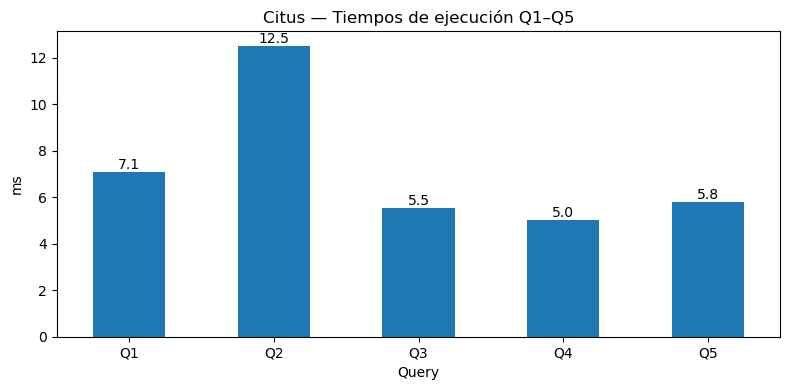

Guardado: outputs/citus_tiempos.csv (para el informe y la comparativa P11)


In [25]:
if CITUS_AVAILABLE and times:
    descripciones = {
        'Q1': 'Búsqueda textual multi-término (ts_rank)',
        'Q2': 'Búsqueda con exclusión (!Twitter)',
        'Q3': 'Top 10 por fecha (ORDER BY published DESC)',
        'Q4': 'GROUP BY section (shard key, local)',
        'Q5': 'GROUP BY news_paper (scatter/gather)',
    }
    tiempos_df = pd.DataFrame({
        'Query': list(times.keys()),
        'Descripción': [descripciones[q] for q in times],
        'Tiempo (ms)': list(times.values()),
    }).set_index('Query')
    display(tiempos_df)

    ax = tiempos_df['Tiempo (ms)'].plot(kind='bar', figsize=(8, 4), rot=0,
                                         title='Citus — Tiempos de ejecución Q1–Q5')
    ax.set_ylabel('ms')
    ax.bar_label(ax.containers[0], fmt='%.1f')
    plt.tight_layout()
    plt.show()

    tiempos_df.to_csv('../../outputs/citus_tiempos.csv')
    print('Guardado: outputs/citus_tiempos.csv (para el informe y la comparativa P11)')
else:
    print('P9: ejecutar primero Q1–Q5 con el cluster activo.')

## P8: Análisis del índice GIN para búsqueda textual

El índice GIN (Generalized Inverted Index) en PostgreSQL:
- Almacena un **índice invertido** de lexemas a posiciones
- `to_tsvector('spanish', texto)` tokeniza, hace stemming y elimina stop words
- `ts_rank` implementa una variante de **TF-IDF** con normalización
- El índice GIN se distribuye entre workers de Citus (cada worker tiene su propio GIN local)
- `Custom Scan (Citus)` en EXPLAIN indica que Citus distribuye la consulta a los workers

## P10: Paralelización en Citus

Revisar EXPLAIN ANALYZE de Q4 vs Q5 para ver:
- Q4 (GROUP BY section): `Task Count: 2` (un task por worker), merge local rápido
- Q5 (GROUP BY news_paper): `Task Count: 2` + scatter/gather (coordinator mergea resultados)
- Presencia de `Custom Scan (Citus)` indica distribución

In [ ]:
print("=== Resumen para informe ===")
print(f"Registros totales: {len(df)}")
print(f"Secciones: {df['section'].nunique()}")
print(f"Periódicos: {df['news_paper'].nunique()}")
print(f"Distribución: HASH sobre section")